### 第6章 利用可视化分析
#### 6.1 绘制渐变饼图分析销量占比情况

      宝贝总数量
区域            
A区          108
B区           61
E区           40
F区           25
G区           19


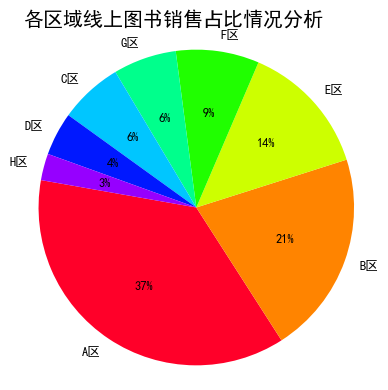

In [3]:
# 导入相关模块
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import numpy as np

# 设置数据显示的列数和宽度
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)
# 解决数据输出时列名不对齐的问题
pd.set_option("display.unicode.east_asian_width", True)
# 读取Excel文件指定列数据（“买家会员名”和“收货地址”）
df = pd.read_excel("mrbooks.xlsx", usecols=["区域", "宝贝总数量"])
# 按区域统计销售数量
# df=df.groupby('区域').sum()
df = df.groupby("区域").sum().sort_values(by="宝贝总数量", ascending=False)
print(df.head())  # 显示前5条数据

# 绘制渐变饼形图
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码
plt.style.use("ggplot")  # 设置图表风格
# 标签
labels = df.index
# 数量
sizes = df["宝贝总数量"]
# 创建子图，设置画布大小
# 返回画布和坐标轴对象
fig, ax = plt.subplots(figsize=(4, 4))
# gist_rainbow为颜色，将数据映射到颜色
# 生成与“宝贝总数量”长度一致的数据集
# 将数据集处理为0~1之间的数据
colors = cm.gist_rainbow(np.arange(len(sizes)) / len(sizes))
# 绘制饼形图
ax.pie(
    sizes,  # 绘图数据
    labels=labels,  # 添加区域水平标签
    autopct="%1.0f%%",  # 设置百分比的格式，这里保留整数
    shadow=False,  # 是否带阴影
    startangle=170,  # 设置饼图的初始角度
    colors=colors,  # 设置饼图颜色
    textprops={"fontsize": 9, "color": "k"},
)  # 设置文本标签的属性值
# 设置x，y轴刻度一致，保证饼图为圆形
ax.axis("equal")
# 图表标题
ax.set_title("各区域线上图书销售占比情况分析", loc="left")
# 图形元素进行一定程度的自适应
plt.tight_layout()
# 显示图表
plt.show()

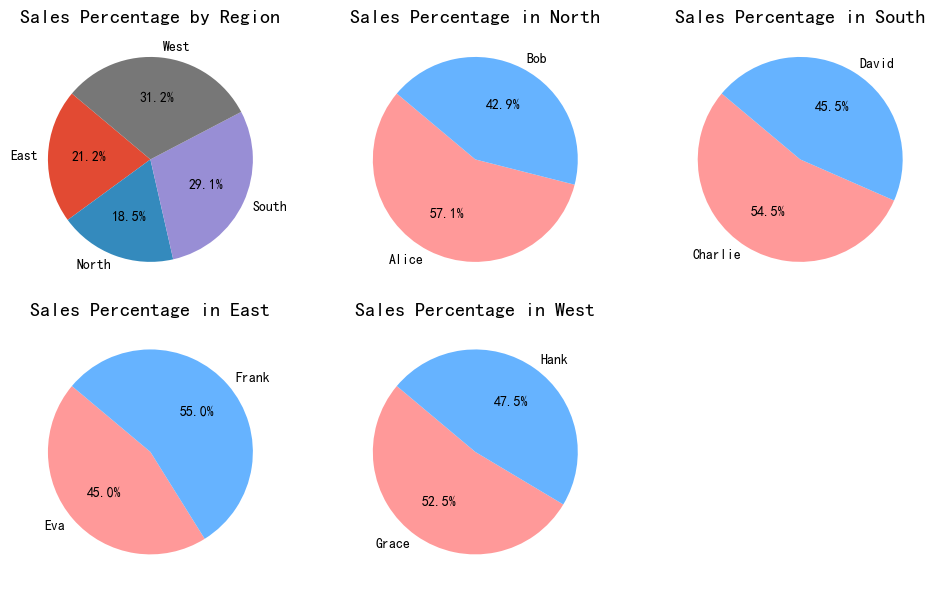

各区域销售占比：
Region
East     21.164021
North    18.518519
South    29.100529
West     31.216931
Name: Sales, dtype: float64

各区域内部销售经理的销售占比：
Region  Manager
East    Eva        180
        Frank      220
North   Alice      200
        Bob        150
South   Charlie    300
        David      250
West    Grace      310
        Hank       280
Name: Sales, dtype: int64


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 数据准备
data = {
    'Region': ['North', 'North', 'South', 'South', 'East', 'East', 'West', 'West'],
    'Manager': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Hank'],
    'Sales': [200, 150, 300, 250, 180, 220, 310, 280]
}
df = pd.DataFrame(data)

# 2. 数据处理
# 按区域汇总
region_sales = df.groupby('Region')['Sales'].sum()
region_percentage = (region_sales / region_sales.sum()) * 100
# 按区域和销售经理汇总
manager_sales = df.groupby(['Region', 'Manager'])['Sales'].sum()

# 3. 数据可视化
# 绘制整体区域销售占比图
plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
region_percentage.plot(kind='pie', autopct='%1.1f%%', startangle=140, 
                       color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title("Sales Percentage by Region")
plt.ylabel('')
# 绘制各区域内部销售经理的销售占比图
regions = df['Region'].unique()
for i, region in enumerate(regions, start=2):
    plt.subplot(2, 3, i)
    region_data = manager_sales[region]
    region_data.plot(kind="pie", autopct='%1.1f%%', startangle=140, colors=['#ff9999', '#66b3ff'])
    plt.title(f"Sales Percentage in {region}")
    plt.ylabel('')
plt.tight_layout()
plt.show()

# 4. 结果分析
print("各区域销售占比：")
print(region_percentage)
print("\n各区域内部销售经理的销售占比：")
print(manager_sales)

#### 6.2 绘制双向柱图分析个人收入与支出

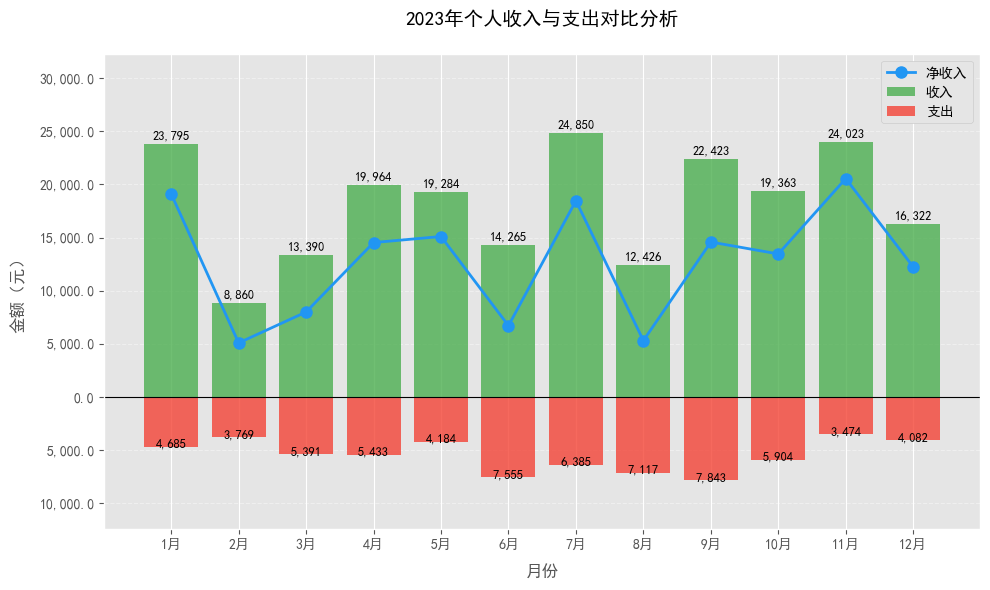

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
# 设置样式
plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文显示问题
plt.rcParams["axes.unicode_minus"] = False      # 解决负号显示问题

# 设置随机种子保证可重复性
np.random.seed(42)
# 定义月份
months = ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月']
n = len(months)
# 生成模拟数据
income = np.random.randint(8000, 25000, n)
expenses = np.random.randint(3000, 8000, n) # 支出下限设为3000
# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))
# 绘制柱形图
income_bars = ax.bar(months, income, color='#4CAF50', alpha=0.8, label='收入')
expenses_bars = ax.bar(months, -expenses, color='#F44336', alpha=0.8, label='支出')
# 添加数据标签
def add_value_labels(bars, is_negative=False):
    for bar in bars:
        height = bar.get_height()
        offset = 0.03 * max(income) if not is_negative else -0.03 * max(income)
        ax.annotate(f'{abs(height):,}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height + offset if not is_negative else height - offset),
                    ha='center', va='center' if not is_negative else 'top', fontsize=9, color='black')
add_value_labels(income_bars)
add_value_labels(expenses_bars, is_negative=True)
# 添加净收入线
net_income = income - expenses
ax.plot(months, net_income, 'o-', color='#2196F3', linewidth=2, markersize=8, label='净收入')
# 添加零线
ax.axhline(0, color='black', linewidth=0.8)
# 设置 y 轴格式 - 添加千位分隔符
def thousands_formatter(x, pos):
    return f'{abs(x):,}'
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
# 设置图表标题和标签
ax.set_title('2023年个人收入与支出对比分析', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('月份', labelpad=10)
ax.set_ylabel('金额（元）', labelpad=10)
# 设置图例
ax.legend(loc='upper right', framealpha=1)
# 调整坐标范围
max_value = max(income.max(), expenses.max())
ax.set_ylim(-max_value * 0.5, max_value * 1.3)
# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()